In [8]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# 1. Produto de ARRANJO (pixel a pixel) - O padrão em PDI
prod_arranjo = a * b

# 2. Produto de MATRIZ (álgebra linear)
# O '@' é o operador para multiplicação de matrizes no NumPy ou np.dot(a, b)
prod_matrix = a @ b


### 2.6.2 Operações Lineares vs. Não Lineares

- A Ideia Central: Uma operação H é linear se `H(a*f1 + b*f2) = a*H(f1) + b*H(f2)`. Em termos simples: a operação aplicada à soma ponderada é igual à soma ponderada do resultado da operação em cada parte. 


- Tradução para Código: Vamos testar os operadores soma (que é linear) e max (que é não linear), exatamente como o livro faz.

In [11]:
# Testando a Linearidade

f1 = np.array([[0, 2], [2, 3]])
f2 = np.array([[6, 5], [4, 7]])

a1 = 1
a2 = -1

# --- Teste com o operador MAX (NÃO LINEAR) ---
print("--- Testando o operador MAX (NÃO LINEAR) ---")

# Lado esquerdo da equação: H(a1*f1 + a2*f2)
lado_esquerdo_max = np.max(a1*f1 + a2*f2)
print("Resultado do lado esquerdo (max):", lado_esquerdo_max)

# Lado direito da equação: a1*H(f1) + a2*H(f2)
lado_direito_max = a1*np.max(f1) + a2*np.max(f2)
print("Resultado do lado direito (max):", lado_direito_max) 

print("Os lados são iguais?", lado_esquerdo_max == lado_direito_max)
print("Conclusão: O operador MAX é NÃO LINEAR.")

# --- Teste com o operador SOMA (LINEAR) ---
print("\n--- Testando o operador SOMA (LINEAR) ---")

# Lado esquerdo da equação: sum(a1*f1 + a2*f2)
lado_esquerdo_sum = np.sum(a1*f1 + a2*f2)
print("Resultado do lado esquerdo (soma):", lado_esquerdo_sum)

# Lado direito da equação: a1*sum(f1) + a2*sum(f2)
lado_direito_sum = a1*np.sum(f1) + a2*np.sum(f2)
print("Resultado do lado direito (soma):", lado_direito_sum)

print("Os lados são iguais?", lado_esquerdo_sum == lado_direito_sum) # True
print("Conclusão: O operador SOMA é LINEAR.")

--- Testando o operador MAX (NÃO LINEAR) ---
Resultado do lado esquerdo (max): -2
Resultado do lado direito (max): -4
Os lados são iguais? False
Conclusão: O operador MAX é NÃO LINEAR.

--- Testando o operador SOMA (LINEAR) ---
Resultado do lado esquerdo (soma): -15
Resultado do lado direito (soma): -15
Os lados são iguais? True
Conclusão: O operador SOMA é LINEAR.


### 2.6.3 Operações Aritméticas

A Ideia Central: Adicionar, subtrair, multiplicar ou dividir imagens, sempre pixel a pixel.  As aplicações são muito práticas:


Adição: Reduzir ruído (Exemplo 2.5, a imagem da galáxia). 


Subtração: Realçar diferenças (Exemplo 2.6, a angiografia). 


Multiplicação/Divisão: Corrigir sombreamento ou aplicar máscaras (Exemplo 2.7). 

Tradução para Código:

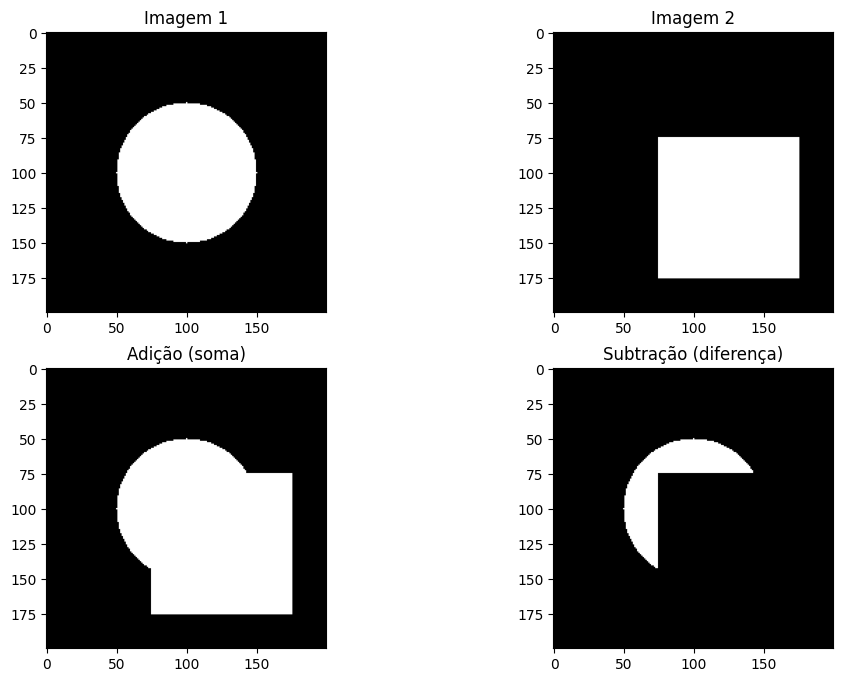

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Para os exemplos, vamos criar duas imagens sintéticas simples
img1 = np.zeros((200, 200), dtype=np.uint8)
img2 = np.zeros((200, 200), dtype=np.uint8)

# Desenha um círculo branco na img1 e um retângulo na img2
cv2.circle(img1, (100, 100), 50, 255, -1)
cv2.rectangle(img2, (75, 75), (175, 175), 255, -1)

# Adição (cv2.add lida com o overflow, valores > 255 viram 255)
img_add = cv2.add(img1, img2) # s(x,y) = f(x,y) + g(x,y)

# Subtração (mostra as diferenças)
img_sub = cv2.subtract(img1, img2) # d(x,y) = f(x,y) - g(x,y)

# Multiplicação (não tão comum, mas usada para mascaramento)
# p(x,y) = f(x,y) * g(x,y) [cite: 60]

# Divisão (não tão comum, usada para correção de sombreamento)
# v(x,y) = f(x,y) / g(x,y) [cite: 61]


# --- Implementando a escala para exibição (Fórmula 2.6-11) ---
# O livro explica que, para exibir uma imagem resultante (ex: de uma subtração),
# é preciso ajustar seus valores para a faixa [0, 255].
img_sub_escalada = cv2.normalize(img_sub, None, 0, 255, cv2.NORM_MINMAX)

# Exibindo os resultados
plt.figure(figsize=(12, 8))
plt.subplot(2,2,1), plt.imshow(img1, cmap='gray'), plt.title('Imagem 1')
plt.subplot(2,2,2), plt.imshow(img2, cmap='gray'), plt.title('Imagem 2')
plt.subplot(2,2,3), plt.imshow(img_add, cmap='gray'), plt.title('Adição (soma)')
plt.subplot(2,2,4), plt.imshow(img_sub_escalada, cmap='gray'), plt.title('Subtração (diferença)')
plt.show()

### 2.6.4 Operações com Conjuntos e Lógicas

A Ideia Central: Para imagens binárias (preto e branco), usamos operações lógicas como AND, OR, NOT, XOR. Elas correspondem à interseção, união e complemento de conjuntos. 

Tradução para Código: É a tradução visual da Figura 2.33 do livro. 

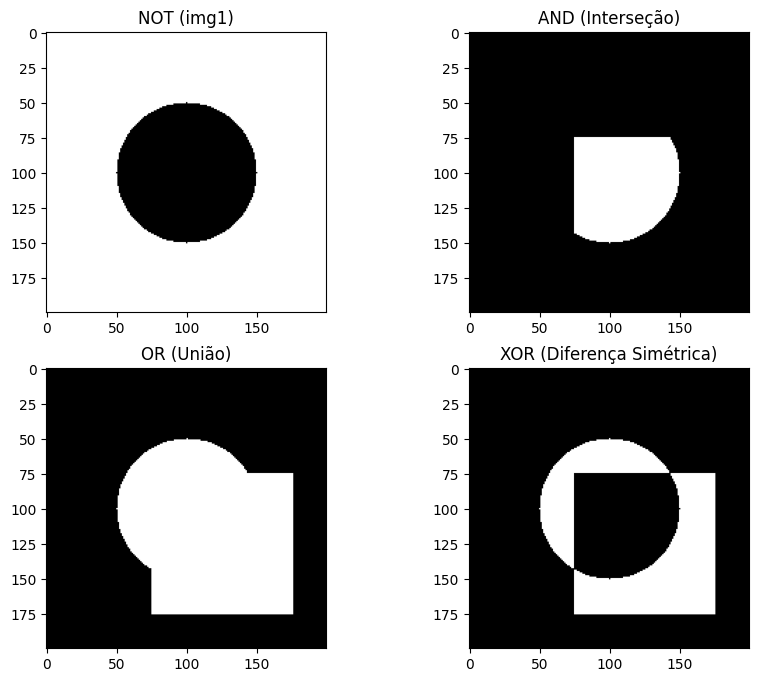

In [13]:
# Usando as mesmas imagens de círculo e retângulo
# Operações Lógicas (Bitwise)

# NOT (Inverte as cores)
img_not = cv2.bitwise_not(img1)

# AND (Interseção: só fica branco onde AMBAS as imagens são brancas)
img_and = cv2.bitwise_and(img1, img2)

# OR (União: fica branco onde UMA OU OUTRA imagem é branca)
img_or = cv2.bitwise_or(img1, img2)

# XOR (OU Exclusivo: fica branco onde uma é branca e a outra é preta)
img_xor = cv2.bitwise_xor(img1, img2)

# Exibindo
plt.figure(figsize=(10, 8))
plt.subplot(2,2,1), plt.imshow(img_not, cmap='gray'), plt.title('NOT (img1)')
plt.subplot(2,2,2), plt.imshow(img_and, cmap='gray'), plt.title('AND (Interseção)')
plt.subplot(2,2,3), plt.imshow(img_or, cmap='gray'), plt.title('OR (União)')
plt.subplot(2,2,4), plt.imshow(img_xor, cmap='gray'), plt.title('XOR (Diferença Simétrica)')
plt.show()

### 2.6.5 Operações Espaciais

A Ideia Central: Operações feitas diretamente nos pixels. 

Ponto a ponto: Altera cada pixel baseado apenas no seu próprio valor (ex: negativo). 

Vizinhança: Altera cada pixel baseado nos seus vizinhos (ex: blur/suavização). 

Geométrica: Muda a posição dos pixels (ex: rotação). 

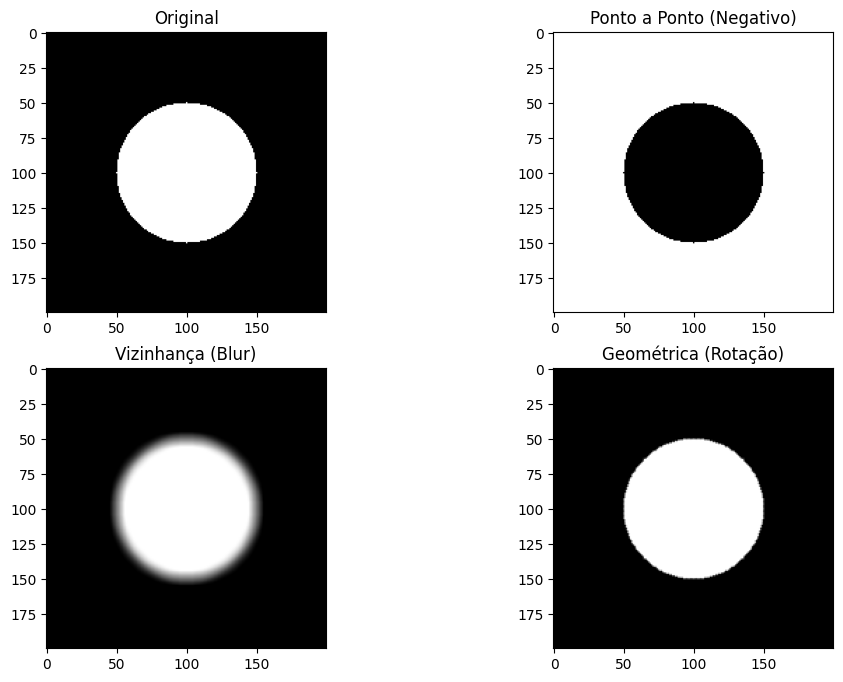

In [ ]:
# Vamos precisar de uma imagem real para ver os efeitos
# Carregue uma imagem sua ou use a 'img1' do círculo
# img_teste = cv2.imread('caminho/para/sua/imagem.jpg', 0) # 0 para ler em escala de cinza

img_teste = img1.copy()

# 1. Operação Ponto a Ponto: Negativo (Equação s = T(z)) [cite: 312]
#    A Figura 2.34 mostra o gráfico dessa transformação. [cite: 346]
img_negativo = 255 - img_teste

# 2. Operação por Vizinhança: Blur (Média da vizinhança)
#    Exemplo da Figura 2.35
img_blur = cv2.blur(img_teste, (11, 11)) # Usa uma vizinhança 11x11

# 3. Transformação Geométrica: Rotação
#    Exemplo da Figura 2.36
rows, cols = img_teste.shape
# Calcula a matriz de transformação afim para rotação (Tabela 2.2) [cite: 377, 379]
M = cv2.getRotationMatrix2D(center=(cols/2, rows/2), angle=45, scale=1)
img_rotacionada = cv2.warpAffine(img_teste, M, (cols, rows))

# Exibindo
plt.figure(figsize=(12, 8))
plt.subplot(2,2,1), plt.imshow(img_teste, cmap='gray'), plt.title('Original')
plt.subplot(2,2,2), plt.imshow(img_negativo, cmap='gray'), plt.title('Ponto a Ponto (Negativo)')
plt.subplot(2,2,3), plt.imshow(img_blur, cmap='gray'), plt.title('Vizinhança (Blur)')
plt.subplot(2,2,4), plt.imshow(img_rotacionada, cmap='gray'), plt.title('Geométrica (Rotação)')
plt.show()

### 2.6.6 a 2.6.8: Vetores, Matrizes, Transformadas e Probabilidade
Essas seções são mais introdutórias a tópicos que serão aprofundados depois.

- **2.6.6 (Vetores):** 
    - A ideia é que um pixel colorido é um vetor. Em uma imagem RGB, cada pixel é um vetor de 3 dimensões (Vermelho, Verde, Azul). 

- **2.6.7 (Transformadas):** 
    - A ideia é que às vezes é mais fácil processar uma imagem em outro "domínio" (como o de frequência com a Transformada de Fourier) e depois voltar. O Exemplo 2.11 e a Figura 2.40 mostram isso. 

- **2.6.8 (Probabilidade):** 
    - A ideia é descrever a imagem com estatísticas. A média (m) e o desvio padrão (σ) dos valores dos pixels nos dão uma noção do brilho e contraste da imagem (Exemplo 2.12, fotos de Einstein). 

Pixel na posição (50, 50) é um vetor: [255   0   0]
Dimensões da imagem colorida: (100, 100, 3)

Estatísticas da imagem em escala de cinza:
Intensidade Média (brilho): 7.25
Desvio Padrão (contraste): 12.56



/tmp/ipykernel_336106/2267011796.py:24: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]))


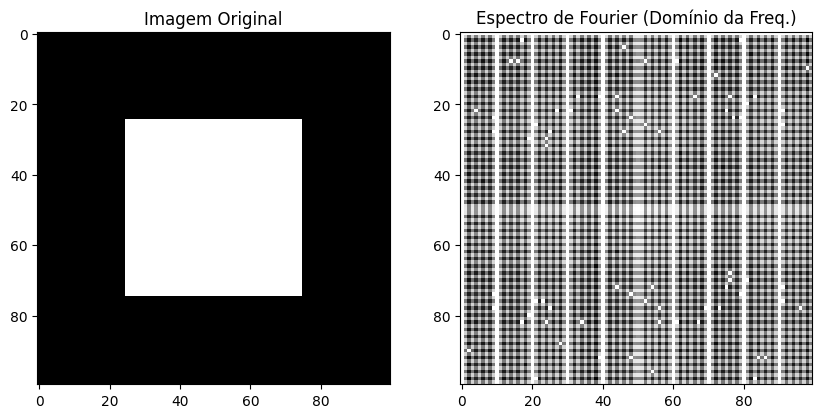

In [17]:
# Crie uma imagem colorida simples
img_color = np.zeros((100, 100, 3), dtype=np.uint8)
img_color[25:75, 25:75] = [255, 0, 0] # Quadrado azul (OpenCV é BGR)

# 2.6.6 - Pixel como um Vetor
pixel_vetor = img_color[50, 50]
print(f"Pixel na posição (50, 50) é um vetor: {pixel_vetor}")
print(f"Dimensões da imagem colorida: {img_color.shape}\n") # (altura, largura, 3 canais)

# 2.6.8 - Métodos Probabilísticos
img_cinza = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

media = np.mean(img_cinza)
desvio_padrao = np.std(img_cinza)

print(f"Estatísticas da imagem em escala de cinza:")
print(f"Intensidade Média (brilho): {media:.2f}")
print(f"Desvio Padrão (contraste): {desvio_padrao:.2f}\n")

# 2.6.7 - "Prévia" da Transformada de Fourier
dft = cv2.dft(np.float32(img_cinza), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
# Magnitude do espectro para visualização
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]))

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1), plt.imshow(img_cinza, cmap='gray'), plt.title('Imagem Original')
plt.subplot(1,2,2), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title('Espectro de Fourier (Domínio da Freq.)')
plt.show()